In [1]:
import jax 
import jax.numpy as jnp
from scoresbibm.src.utils.data_utils import load_model
#jax.config.update("jax_platform_name", "cpu")
from scoresbibm.src.tasks.unstructured_tasks import LotkaVolterraTask

from functools import partial
from probjax.utils.odeint import _odeint
from probjax.utils.jaxutils import ravel_args
from probjax.core import joint_sample, log_potential_fn,rv, intervene
from probjax.distributions import Normal, Uniform, Independent
from probjax.distributions.transformed_distribution import TransformedDistribution
from probjax.inference.mcmc import MCMC 
from probjax.inference.marcov_kernels import HMCKernel, GaussianMHKernel, SliceKernel, LangevianMHKernel


import matplotlib.pyplot as plt

/mnt/qb/work/macke/mgloeckler90/miniconda3/envs/probjax/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
task = LotkaVolterraTask()

In [3]:
base_mask_fn = task.get_base_mask_fn()

In [5]:
data = task.get_data(1000, rng=jax.random.PRNGKey(0))


In [6]:
observation_generator = task.get_observation_generator()
observation_stream = observation_generator(jax.random.PRNGKey(0))

In [7]:


while True:
    condition_mask, x_o, theta_o, meta_data, node_id = next(observation_stream)
    condition_mask_wanted = jnp.array([False,False, False,False] + [True]*(len(condition_mask)-4))
    if jnp.all(condition_mask == condition_mask_wanted):
        break   

In [138]:
id_params1 = (node_id == 0) | (node_id == 1)
id_params2 = (node_id == 2) | (node_id == 3)
id_mask1 = node_id == 4
id_mask2 = node_id == 5

max_points = node_id.shape[0]
indices1 = jnp.where(id_mask1, size=max_points)[0]
indices2 = jnp.where(id_mask2, size=max_points)[0]
indices_params1 = jnp.where(id_params1, size=max_points)[0]
indices_params2 = jnp.where(id_params2, size=max_points)[0]

mask = jnp.eye(node_id.shape[0], dtype=bool)

distances = jnp.abs(meta_data[None,:] - meta_data[:, None])
cross_distances = distances * (id_mask1[None, :] & id_mask2[:, None]) + ~(id_mask1[None, :] & id_mask2[:, None]) * jnp.inf
closest_value = jnp.argmin(cross_distances, axis=1)

mask = mask.at[indices1[1:], indices1[:-1]].set(True)
mask = mask.at[indices2[1:], indices2[:-1]].set(True)
mask = mask.at[jnp.arange(mask.shape[0]), closest_value].set(True)
mask = mask.at[0, :].set(False)
mask = mask.at[:, 0].set(False)
mask = mask.at[0, 0].set(True)
mask = mask | id_params1[None,:] & id_mask1[:, None]
mask = mask | id_params2[None,:] & id_mask2[:, None]

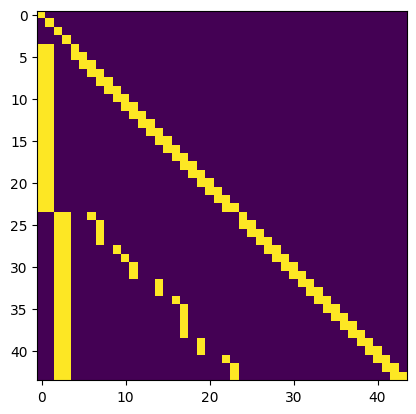

In [139]:
plt.imshow(mask)

In [69]:
jnp.argmin(cross_distances, axis=0)

Array([ 0,  0,  0,  0, 24, 24, 24, 27, 28, 29, 29, 29, 32, 32, 33, 34, 34,
       38, 38, 40, 40, 40, 41, 42,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0], dtype=int32)

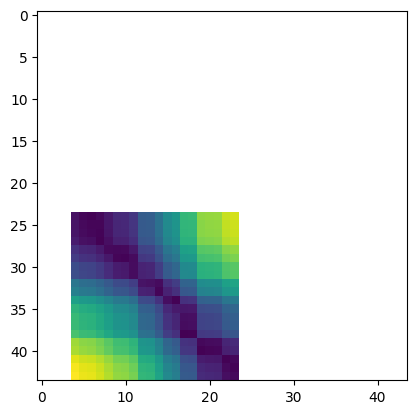

In [52]:
plt.imshow(cross_distances)

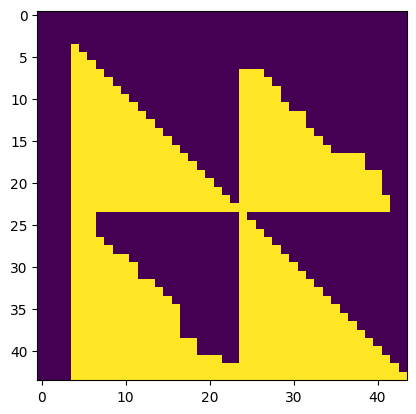

In [13]:
plt.imshow(past_values)

In [25]:
data = task.get_data(2, rng=jax.random.PRNGKey(0))

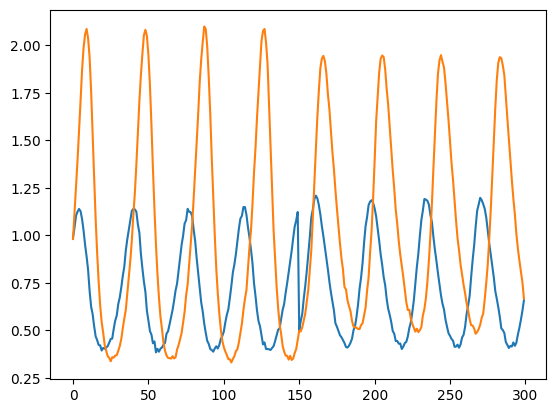

In [9]:
plt.plot(data["x"].T)

In [6]:
model = load_model("results/lotka_volterra",0)

In [21]:
observation_generator = task.get_observation_generator()
observation_stream = observation_generator(jax.random.PRNGKey(1))

In [22]:


while True:
    condition_mask, x_o, theta_o, meta_data, node_id = next(observation_stream)
    condition_mask_wanted = jnp.array([True,True, True,True] + [False]*(len(condition_mask)-4))
    if jnp.all(condition_mask == condition_mask_wanted):
        break   

In [23]:
with jax.default_device(jax.devices("cuda")[0]):
    samples = model.sample(500, rng=jax.random.PRNGKey(0), condition_mask=condition_mask, x_o=x_o, meta_data=meta_data, node_id=node_id)

In [24]:
model_ref = task.get_reference_sampler()
samples_ref = model_ref.sample(500, rng=jax.random.PRNGKey(1), condition_mask=condition_mask, x_o=x_o, meta_data=meta_data, node_id=node_id)

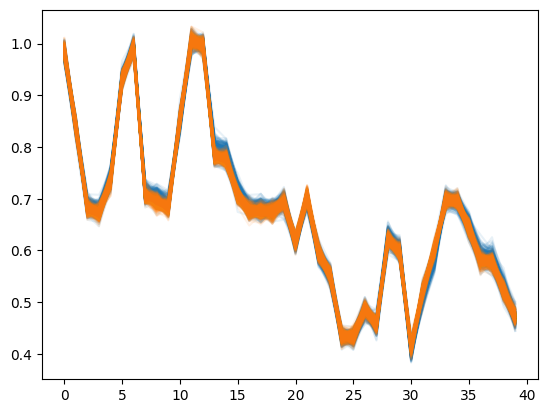

In [27]:
_ =plt.plot(samples.T, alpha=0.1, color="C0")
_ = plt.plot(samples_ref.T, alpha=0.1, color="C1")

(<Figure size 1000x1000 with 16 Axes>,
 array([[<Axes: xlabel='dim 1'>, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: xlabel='dim 2'>, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: xlabel='dim 3'>, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >, <Axes: xlabel='dim 4'>]],
       dtype=object))

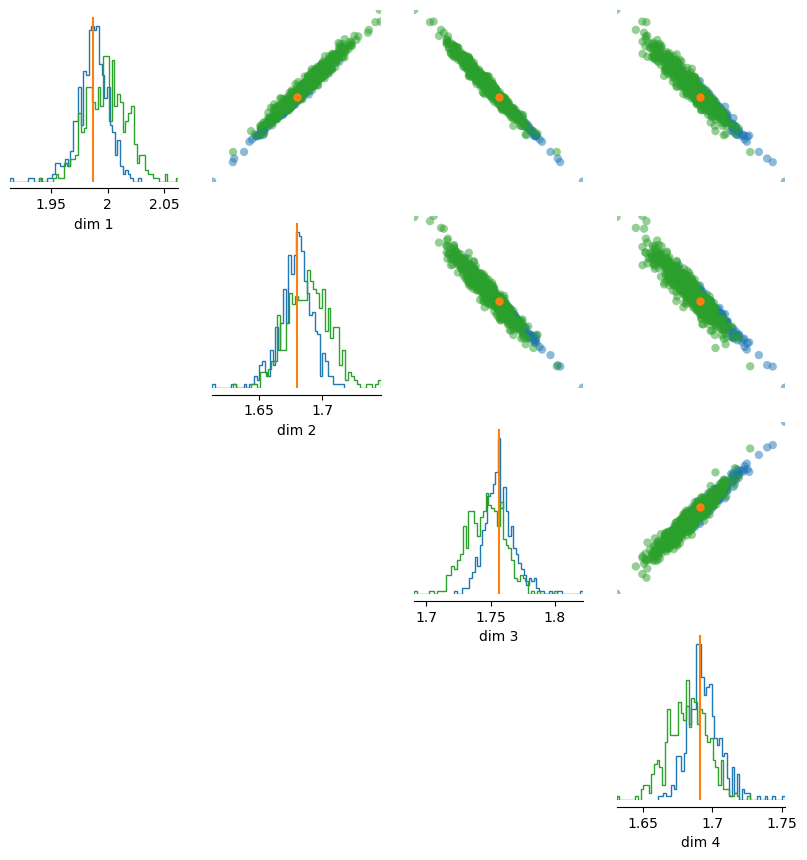

In [15]:
from sbi.analysis import pairplot
import numpy as np 

samples_ref = np.array(samples_ref)
samples = np.array(samples)
pairplot([samples_ref,samples], figsize=(10, 10), points=np.array(theta_o), upper="scatter")

In [16]:
samples = model.sample(200, rng=jax.random.PRNGKey(0), condition_mask=condition_mask, x_o=x_o, theta_o=theta_o, meta_data=meta_data)

TypeError: cannot reshape array of shape (44,) (size 44) into shape 304 (size 304)

In [ ]:
meta_data.shape

(44,)

ValueError: x and y must have same first dimension, but have shapes (20,) and (4, 200)

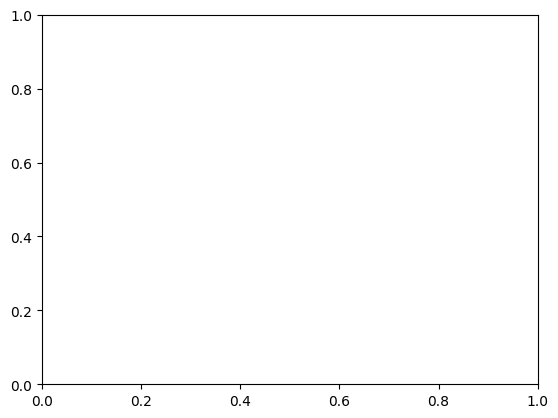

In [ ]:

_ = plt.plot(meta_data[4:24],samples[:,:20].T, ".", color="C0", alpha=0.1)

In [30]:
theta_o

Array([2.244, 2.824, 2.715, 2.605], dtype=float32)

(<Figure size 1000x1000 with 4 Axes>,
 array([[<Axes: xlabel='dim 1'>, <Axes: >],
        [<Axes: >, <Axes: xlabel='dim 2'>]], dtype=object))

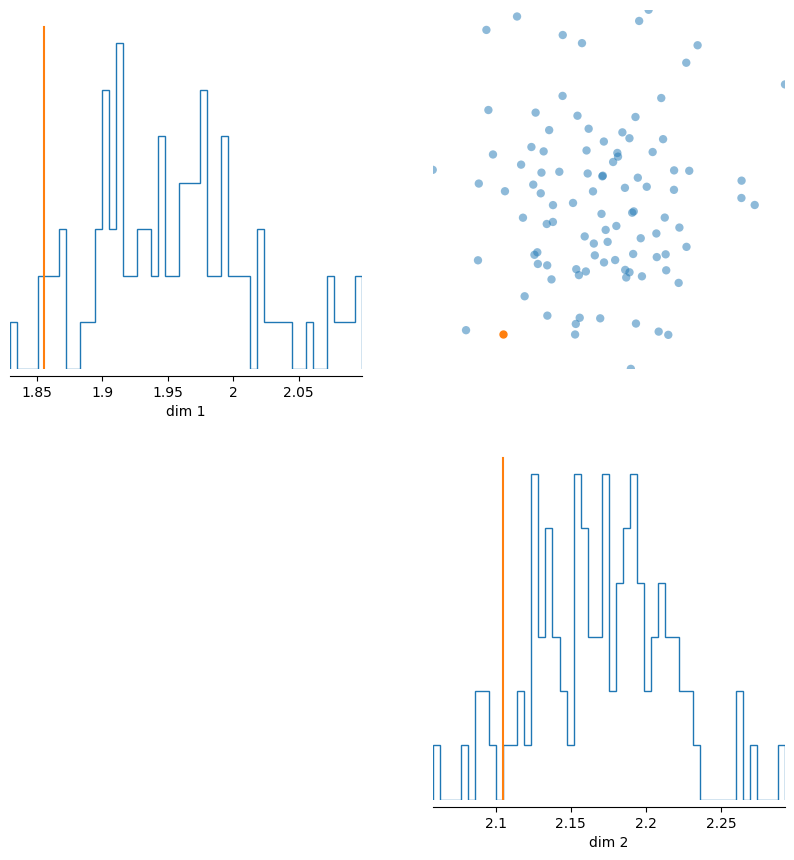

In [26]:
from sbi.analysis import pairplot
import numpy as np 

samples = np.array(samples)
pairplot(samples, figsize=(10, 10), points=np.array(theta_o), upper="scatter")

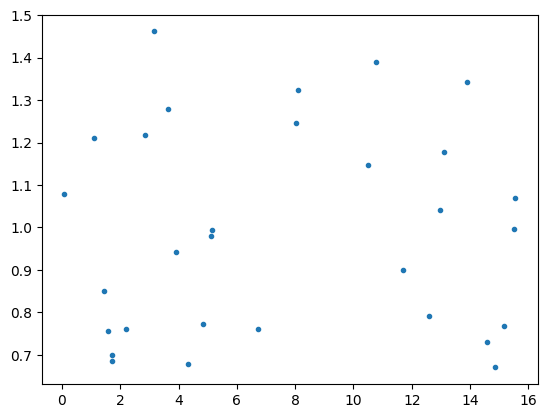

In [29]:
plt.plot(meta_data[4:34],x_o[:30], ".")